In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv("/xy_data.csv")
print(df.head())

            x          y
0   88.364456  57.784378
1   74.283936  54.406780
2   60.256474  46.311462
3   82.134370  57.717567
4  101.036390  67.849340


Dataset loaded successfully
Number of points: 1500
            x          y
0   88.364456  57.784378
1   74.283936  54.406780
2   60.256474  46.311462
3   82.134370  57.717567
4  101.036390  67.849340

Starting global optimization...
Refining solution...

FINAL PARAMETER ESTIMATION RESULTS
Theta (degrees): 30.00032030
Theta (radians): 0.52360437
M:               0.0299999244
X:               55.00042683
Final L1 Loss:   0.0225998478

Desmos Expression:
(t * cos(0.52360437) - e^(0.02999992 * |t|) * sin(0.3 * t) * sin(0.52360437) + 55.00042683, 42 + t * sin(0.52360437) + e^(0.02999992 * |t|) * sin(0.3 * t) * cos(0.52360437))

Domain: 6 < t < 60


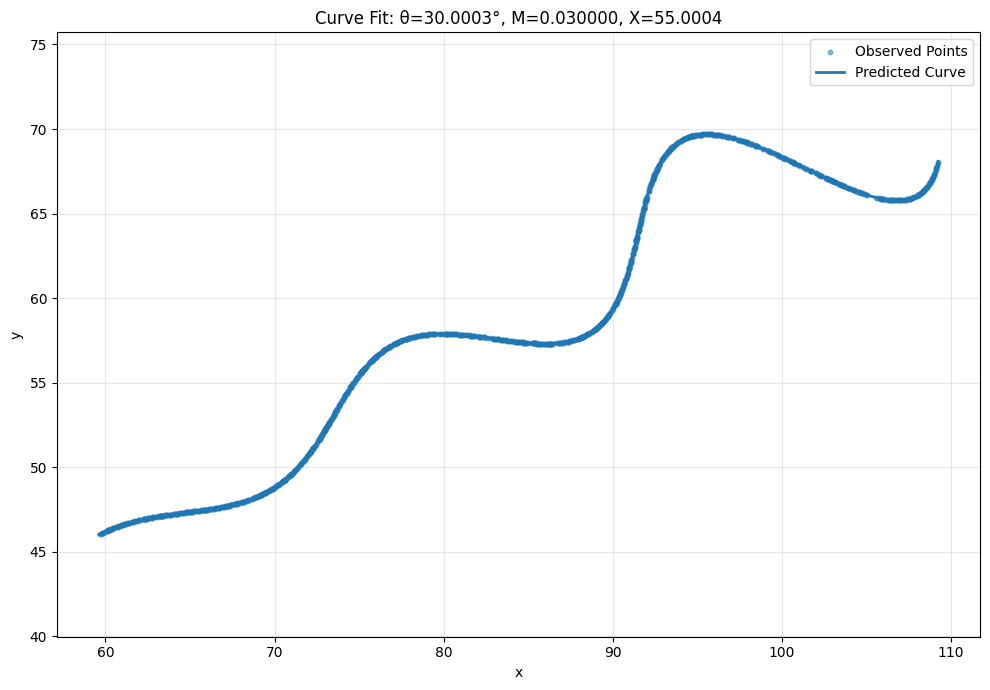


Files saved successfully:
results.png
estimated_parameters.csv


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution, minimize
from scipy.spatial import cKDTree


DATA_FILE = "/xy_data.csv"

df = pd.read_csv(DATA_FILE)

cols = {column.lower().strip(): column for column in df.columns}

if "x" not in cols or "y" not in cols:
    raise ValueError(
        f"Dataset must contain 'x' and 'y' columns. Found: {df.columns.tolist()}"
    )

x_data = df[cols["x"]].to_numpy(dtype=float)
y_data = df[cols["y"]].to_numpy(dtype=float)

observed_points = np.column_stack((x_data, y_data))
observed_tree = cKDTree(observed_points)

print("Dataset loaded successfully")
print("Number of points:", len(observed_points))
print(df.head())


def generate_curve(theta_deg, M, X, n_points=1000):
    theta = np.deg2rad(theta_deg)
    t = np.linspace(6, 60, n_points)

    oscillation = np.exp(M * np.abs(t)) * np.sin(0.3 * t)

    x = (
        t * np.cos(theta)
        - oscillation * np.sin(theta)
        + X
    )

    y = (
        42
        + t * np.sin(theta)
        + oscillation * np.cos(theta)
    )

    return np.column_stack((x, y))


def curve_loss(params):
    theta_deg, M, X = params

    predicted_points = generate_curve(
        theta_deg,
        M,
        X,
        n_points=1000
    )

    predicted_tree = cKDTree(predicted_points)

    d_obs_to_pred, _ = predicted_tree.query(
        observed_points,
        k=1,
        p=1
    )

    d_pred_to_obs, _ = observed_tree.query(
        predicted_points,
        k=1,
        p=1
    )

    return 0.5 * (
        np.mean(d_obs_to_pred)
        + np.mean(d_pred_to_obs)
    )


bounds = [
    (0.0001, 49.9999),
    (-0.0499, 0.0499),
    (0.0001, 99.9999)
]


print("\nStarting global optimization...")

global_result = differential_evolution(
    curve_loss,
    bounds=bounds,
    strategy="best1bin",
    maxiter=250,
    popsize=15,
    tol=1e-7,
    seed=42,
    workers=-1,
    updating="deferred",
    polish=False
)


print("Refining solution...")

local_result = minimize(
    curve_loss,
    global_result.x,
    method="Nelder-Mead",
    options={
        "maxiter": 5000,
        "xatol": 1e-10,
        "fatol": 1e-10
    }
)


candidate = local_result.x

if (
    0 < candidate[0] < 50
    and -0.05 < candidate[1] < 0.05
    and 0 < candidate[2] < 100
):
    final_params = candidate
    final_loss = curve_loss(candidate)
else:
    final_params = global_result.x
    final_loss = global_result.fun


theta_final, M_final, X_final = final_params
theta_rad = np.deg2rad(theta_final)

final_curve = generate_curve(
    theta_final,
    M_final,
    X_final,
    n_points=5000
)


print("\n" + "=" * 60)
print("FINAL PARAMETER ESTIMATION RESULTS")
print("=" * 60)

print(f"Theta (degrees): {theta_final:.8f}")
print(f"Theta (radians): {theta_rad:.8f}")
print(f"M:               {M_final:.10f}")
print(f"X:               {X_final:.8f}")
print(f"Final L1 Loss:   {final_loss:.10f}")


desmos_expression = (
    f"(t * cos({theta_rad:.8f}) "
    f"- e^({M_final:.8f} * |t|) * sin(0.3 * t) * sin({theta_rad:.8f}) "
    f"+ {X_final:.8f}, "
    f"42 + t * sin({theta_rad:.8f}) "
    f"+ e^({M_final:.8f} * |t|) * sin(0.3 * t) * cos({theta_rad:.8f}))"
)

print("\nDesmos Expression:")
print(desmos_expression)

print("\nDomain: 6 < t < 60")


plt.figure(figsize=(10, 7))

plt.scatter(
    x_data,
    y_data,
    s=10,
    alpha=0.5,
    label="Observed Points"
)

plt.plot(
    final_curve[:, 0],
    final_curve[:, 1],
    linewidth=2,
    label="Predicted Curve"
)

plt.xlabel("x")
plt.ylabel("y")

plt.title(
    f"Curve Fit: θ={theta_final:.4f}°, "
    f"M={M_final:.6f}, X={X_final:.4f}"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.tight_layout()

plt.savefig(
    "results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


results = pd.DataFrame({
    "Parameter": [
        "Theta (degrees)",
        "Theta (radians)",
        "M",
        "X",
        "Final L1 Loss"
    ],
    "Value": [
        theta_final,
        theta_rad,
        M_final,
        X_final,
        final_loss
    ]
})

results.to_csv(
    "estimated_parameters.csv",
    index=False
)

print("\nFiles saved successfully:")
print("results.png")
print("estimated_parameters.csv")

In [5]:
from google.colab import files
files.download("results.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
from google.colab import files
files.download("estimated_parameters.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>